# Hypothesis: ARC-AGI-2 Puzzles Without Advanced Geometric Motifs Exhibit Higher Color Complexity and Smaller Bounded Search Spaces

This notebook systematically identifies, filters, and analyzes a distinct subset of ARC-AGI-2 puzzles that contain **absolutely no advanced geometric motifs** (lines, diagonal lines, squares, rectangles, and junctions/corners) in any of their input or output grids. We investigate whether the absence of structural motifs is statistically compensated by higher color variety, smaller grid dimensions, or simpler local connectivity patterns.

## 1. Theoretical Framework and Analytical Methodology

To conduct this analysis, we process the complete ARC-AGI-2 training and evaluation datasets. We implement high-efficiency detection algorithms to scan all grids (input and output of both train and test splits) within each task for advanced geometric motifs. A puzzle is classified as a **No-Motif Puzzle** if and only if every single grid in every pair is completely free of any of the following motifs:
- **Lines**: Same-color horizontal or vertical segments of size $L \ge 3$, excluding background.
- **Diagonal Lines**: Same-color major or minor diagonal segments of size $L \ge 3$, excluding background.
- **Squares**: Solid or hollow/framed same-color squares of size $S \ge 2$.
- **Rectangles**: Unequal dimension same-color rectangles of size $\ge 2 \times 2$.
- **Junctions (Corners)**: Orthogonal or diagonal arm/stem junction segments (such as L-corners, T-shapes, and Crosses).

### 1.1 Analytical Features
For each puzzle, we compile key descriptive statistics to characterize the no-motif subset in comparison to the rest of the corpus:
- `max_dimension`: The maximum of height or width among all grids in the task.
- `unique_colors`: The count of unique non-background colors present across the task's grids.
- `grid_count`: Total number of grids associated with the task.
- `average_density`: The mean ratio of active (non-background) pixels relative to the grid area across all grids.

These features allow us to run rigorous statistical comparisons and testing.

## 2. Explicit Hypotheses

### Hypothesis 1: Color Complexity
- **Null Hypothesis ($H_0^1$)**: Puzzles without advanced geometric motifs have identical median unique color counts compared to puzzles containing advanced motifs.
- **Alternative Hypothesis ($H_a^1$)**: Puzzles without advanced geometric motifs have a significantly higher median count of unique colors, indicating that color variation compensates for the lack of complex geometric structures.

### Hypothesis 2: Spatial Search Space
- **Null Hypothesis ($H_0^2$)**: Puzzles without advanced geometric motifs have identical median grid dimensions compared to puzzles with motifs.
- **Alternative Hypothesis ($H_a^2$)**: Puzzles without advanced geometric motifs have significantly smaller grid dimensions, suggesting that the solver's search space is constrained when geometric rules are absent.

In [1]:
# Environment Setup
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

# Dynamically search parent directories for 'motifs' folder containing the consolidated dataset
export_dir = 'motifs/'
base_path = '.'
for _ in range(5):
    full_path = os.path.join(base_path, export_dir)
    if os.path.exists(full_path) and os.path.exists(os.path.join(full_path, 'arc_training_consolidated.json')):
        export_dir = full_path
        break
    base_path = os.path.join(base_path, '..')

# Ensure Google Colab compatibility override
try:
    from google.colab import drive
    drive.mount('/content/drive')
    export_dir = '/content/drive/MyDrive/motifs/'
except ImportError:
    pass

os.makedirs(export_dir, exist_ok=True)
print(f'Export directory set to: {export_dir}')

Export directory set to: ./../motifs/


In [2]:
# Advanced Motif Detection Routines

def find_lines_fast(grid):
    H, W = len(grid), len(grid[0])
    lines = []
    # Horizontal lines
    for r in range(H):
        c = 0
        while c < W:
            color = grid[r][c]
            c_start = c
            while c < W and grid[r][c] == color:
                c += 1
            c_end = c - 1
            length = c_end - c_start + 1
            if length >= 3 and color != 0:
                contained_above = False
                if r - 1 >= 0:
                    contained_above = all(grid[r-1][col] == color for col in range(c_start, c_end + 1))
                contained_below = False
                if r + 1 < H:
                    contained_below = all(grid[r+1][col] == color for col in range(c_start, c_end + 1))
                if not (contained_above or contained_below):
                    lines.append(1)
    # Vertical lines
    for c in range(W):
        r = 0
        while r < H:
            color = grid[r][c]
            r_start = r
            while r < H and grid[r][c] == color:
                r += 1
            r_end = r - 1
            length = r_end - r_start + 1
            if length >= 3 and color != 0:
                contained_left = False
                if c - 1 >= 0:
                    contained_left = all(grid[row][c-1] == color for row in range(r_start, r_end + 1))
                contained_right = False
                if c + 1 < W:
                    contained_right = all(grid[row][c+1] == color for row in range(r_start, r_end + 1))
                if not (contained_left or contained_right):
                    lines.append(1)
    return lines

def find_diagonal_lines(grid):
    H, W = len(grid), len(grid[0])
    diag_lines = []
    # Major diagonals (down-right)
    for r in range(H):
        for c in range(W):
            color = grid[r][c]
            if color == 0:
                continue
            if r - 1 >= 0 and c - 1 >= 0 and grid[r-1][c-1] == color:
                continue
            cells = []
            curr_r, curr_c = r, c
            while curr_r < H and curr_c < W and grid[curr_r][curr_c] == color:
                cells.append((curr_r, curr_c))
                curr_r += 1
                curr_c += 1
            length = len(cells)
            if length >= 3:
                contained_ur = True
                for ri, ci in cells:
                    n_r, n_c = ri - 1, ci + 1
                    if not (0 <= n_r < H and 0 <= n_c < W and grid[n_r][n_c] == color):
                        contained_ur = False
                        break
                contained_ll = True
                for ri, ci in cells:
                    n_r, n_c = ri + 1, ci - 1
                    if not (0 <= n_r < H and 0 <= n_c < W and grid[n_r][n_c] == color):
                        contained_ll = False
                        break
                if not (contained_ur or contained_ll):
                    diag_lines.append(1)
    # Minor diagonals (down-left)
    for r in range(H):
        for c in range(W):
            color = grid[r][c]
            if color == 0:
                continue
            if r - 1 >= 0 and c + 1 < W and grid[r-1][c+1] == color:
                continue
            cells = []
            curr_r, curr_c = r, c
            while curr_r < H and curr_c >= 0 and grid[curr_r][curr_c] == color:
                cells.append((curr_r, curr_c))
                curr_r += 1
                curr_c -= 1
            length = len(cells)
            if length >= 3:
                contained_ul = True
                for ri, ci in cells:
                    n_r, n_c = ri - 1, ci - 1
                    if not (0 <= n_r < H and 0 <= n_c < W and grid[n_r][n_c] == color):
                        contained_ul = False
                        break
                contained_lr = True
                for ri, ci in cells:
                    n_r, n_c = ri + 1, ci + 1
                    if not (0 <= n_r < H and 0 <= n_c < W and grid[n_r][n_c] == color):
                        contained_lr = False
                        break
                if not (contained_ul or contained_lr):
                    diag_lines.append(1)
    return diag_lines

def find_squares_optimized(grid):
    H, W = len(grid), len(grid[0])
    squares = []
    coords_by_color = {}
    for r in range(H):
        for c in range(W):
            color = grid[r][c]
            if color != 0:
                if color not in coords_by_color:
                    coords_by_color[color] = []
                coords_by_color[color].append((r, c))
    for color, coords in coords_by_color.items():
        if len(coords) < 4:
            continue
        n = len(coords)
        for i in range(n):
            r1, c1 = coords[i]
            for j in range(i+1, n):
                r2, c2 = coords[j]
                if r1 < r2 and c1 < c2 and (r2 - r1 == c2 - c1):
                    S = r2 - r1 + 1
                    if grid[r2][c1] != color or grid[r1][c2] != color:
                        continue
                    is_boundary_ok = True
                    if S >= 3:
                        for col in range(c1 + 1, c2):
                            if grid[r1][col] != color or grid[r2][col] != color:
                                is_boundary_ok = False
                                break
                        if not is_boundary_ok:
                            continue
                        for row in range(r1 + 1, r2):
                            if grid[row][c1] != color or grid[row][c2] != color:
                                is_boundary_ok = False
                                break
                        if not is_boundary_ok:
                            continue
                    squares.append(1)
    return squares

def find_rectangles_optimized(grid):
    H, W = len(grid), len(grid[0])
    rectangles = []
    coords_by_color = {}
    for r in range(H):
        for c in range(W):
            color = grid[r][c]
            if color != 0:
                if color not in coords_by_color:
                    coords_by_color[color] = []
                coords_by_color[color].append((r, c))
    for color, coords in coords_by_color.items():
        if len(coords) < 4:
            continue
        n = len(coords)
        for i in range(n):
            r1, c1 = coords[i]
            for j in range(i+1, n):
                r2, c2 = coords[j]
                if r1 < r2 and c1 < c2:
                    H_r = r2 - r1 + 1
                    W_r = c2 - c1 + 1
                    if H_r == W_r:
                        continue
                    if grid[r2][c1] != color or grid[r1][c2] != color:
                        continue
                    is_boundary_ok = True
                    for col in range(c1 + 1, c2):
                        if grid[r1][col] != color or grid[r2][col] != color:
                            is_boundary_ok = False
                            break
                    if not is_boundary_ok:
                        continue
                    for row in range(r1 + 1, r2):
                        if grid[row][c1] != color or grid[row][c2] != color:
                            is_boundary_ok = False
                            break
                    if not is_boundary_ok:
                        continue
                    rectangles.append(1)
    return rectangles

def find_junction_motifs(grid):
    H, W = len(grid), len(grid[0])
    motifs = []
    def get_arm_length(r, c, dr, dc, color):
        length = 0
        curr_r = r + dr
        curr_c = c + dc
        while 0 <= curr_r < H and 0 <= curr_c < W and grid[curr_r][curr_c] == color:
            length += 1
            curr_r += dr
            curr_c += dc
        return length
    for r in range(H):
        for c in range(W):
            color = grid[r][c]
            if color == 0:
                continue
            U = get_arm_length(r, c, -1, 0, color)
            D = get_arm_length(r, c, 1, 0, color)
            L = get_arm_length(r, c, 0, -1, color)
            R = get_arm_length(r, c, 0, 1, color)
            arms_std = [U, D, L, R]
            active_std = sum(1 for a in arms_std if a >= 1)
            UL = get_arm_length(r, c, -1, -1, color)
            UR = get_arm_length(r, c, -1, 1, color)
            DL = get_arm_length(r, c, 1, -1, color)
            DR = get_arm_length(r, c, 1, 1, color)
            arms_diag = [UL, UR, DL, DR]
            active_diag = sum(1 for a in arms_diag if a >= 1)
            if active_std == 2:
                for a1, a2, o in [('U', 'L', 'top-left'), ('U', 'R', 'top-right'), ('D', 'L', 'bottom-left'), ('D', 'R', 'bottom-right')]:
                    v1 = U if a1 == 'U' else D
                    v2 = L if a2 == 'L' else R
                    if v1 >= 1 and v2 >= 1:
                        motifs.append(1)
            if active_diag == 2:
                for a1, a2, o in [('UL', 'UR', 'up'), ('UR', 'DR', 'right'), ('DR', 'DL', 'down'), ('DL', 'UL', 'left')]:
                    v1 = UL if a1 == 'UL' else DR
                    v2 = UR if a2 == 'UR' else DL
                    if v1 >= 1 and v2 >= 1:
                        motifs.append(1)
    return motifs

print('Advanced motif detection functions loaded successfully.')

Advanced motif detection functions loaded successfully.


In [3]:
# Load and process training and evaluation datasets
train_path = os.path.join(export_dir, 'arc_training_consolidated.json')
eval_path = os.path.join(export_dir, 'arc_evaluation_consolidated.json')

all_tasks = {}
if os.path.exists(train_path):
    with open(train_path, 'r') as f:
        all_tasks.update(json.load(f))
if os.path.exists(eval_path):
    with open(eval_path, 'r') as f:
        all_tasks.update(json.load(f))

print(f'Loaded {len(all_tasks)} tasks.')

puzzles_data = []
for task_id, task in sorted(all_tasks.items()):
    has_motif = False
    all_grids_in_task = []
    unique_colors_in_task = set()
    densities = []
    max_h = 0
    max_w = 0
    for split in ['train', 'test']:
        for pair in task.get(split, []):
            for key in ['input', 'output']:
                if key in pair:
                    grid = np.array(pair[key])
                    all_grids_in_task.append(grid)
                    h, w = grid.shape
                    max_h = max(max_h, h)
                    max_w = max(max_w, w)
                    active_pixels = np.sum(grid != 0)
                    densities.append(active_pixels / (h * w))
                    for r in range(h):
                        for c in range(w):
                            if grid[r, c] != 0:
                                unique_colors_in_task.add(grid[r, c])
                    # Detect any motif
                    if len(find_lines_fast(grid)) > 0 or \
                       len(find_diagonal_lines(grid)) > 0 or \
                       len(find_squares_optimized(grid)) > 0 or \
                       len(find_rectangles_optimized(grid)) > 0 or \
                       len(find_junction_motifs(grid)) > 0:
                        has_motif = True

    puzzles_data.append({
        'task_id': task_id,
        'has_motif': int(has_motif),
        'grid_count': len(all_grids_in_task),
        'max_dimension': max(max_h, max_w),
        'unique_colors': len(unique_colors_in_task),
        'average_density': np.mean(densities) if densities else 0.0
    })

df_puzzles = pd.DataFrame(puzzles_data)
df_no_motif = df_puzzles[df_puzzles['has_motif'] == 0].copy()
df_with_motif = df_puzzles[df_puzzles['has_motif'] == 1].copy()

print(f'Total puzzles analyzed: {len(df_puzzles)}')
print(f'Puzzles WITH advanced motifs: {len(df_with_motif)}')
print(f'Puzzles WITHOUT advanced motifs: {len(df_no_motif)}')

# Export No-Motif puzzles list
no_motif_export_path = os.path.join(export_dir, 'no_advanced_motifs_puzzles.csv')
df_no_motif.to_csv(no_motif_export_path, index=False)
print(f'No-motif puzzles list successfully exported to {no_motif_export_path}')

Loaded 1120 tasks.


Total puzzles analyzed: 1120
Puzzles WITH advanced motifs: 1099
Puzzles WITHOUT advanced motifs: 21
No-motif puzzles list successfully exported to ./../motifs/no_advanced_motifs_puzzles.csv


## 3. Results with Visualizations and Metrics

We visualize the distribution of unique colors and grid dimensions for both subsets and perform Mann-Whitney U significance tests.

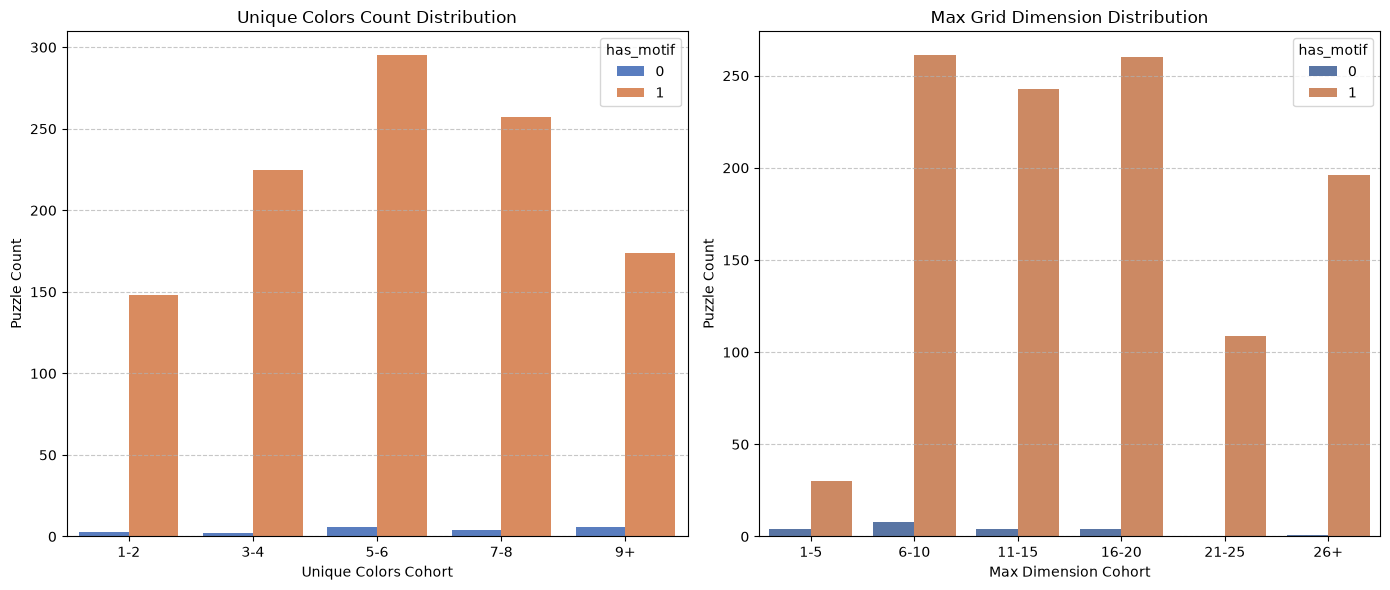

In [4]:
# Visualizations: Binned distributions showing decay profiles
plt.figure(figsize=(14, 6))

# 1. Unique Colors Distribution
plt.subplot(1, 2, 1)
# Bin colors into cohorts
color_bins = [0, 2, 4, 6, 8, np.inf]
color_labels = ['1-2', '3-4', '5-6', '7-8', '9+']
df_puzzles['color_cohort'] = pd.cut(df_puzzles['unique_colors'], bins=color_bins, labels=color_labels, right=True)
sns.countplot(data=df_puzzles, x='color_cohort', hue='has_motif', palette='muted')
plt.title('Unique Colors Count Distribution')
plt.xlabel('Unique Colors Cohort')
plt.ylabel('Puzzle Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 2. Max Dimension Distribution
plt.subplot(1, 2, 2)
dim_bins = [0, 5, 10, 15, 20, 25, np.inf]
dim_labels = ['1-5', '6-10', '11-15', '16-20', '21-25', '26+']
df_puzzles['dim_cohort'] = pd.cut(df_puzzles['max_dimension'], bins=dim_bins, labels=dim_labels, right=True)
sns.countplot(data=df_puzzles, x='dim_cohort', hue='has_motif', palette='deep')
plt.title('Max Grid Dimension Distribution')
plt.xlabel('Max Dimension Cohort')
plt.ylabel('Puzzle Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig(os.path.join(export_dir, 'no_motif_vs_motif_distributions.png'))
plt.show()

In [5]:
# Hypothesis Testing using Mann-Whitney U test

print('=== Mann-Whitney U test: Unique Colors ===')
stat_col, p_col = mannwhitneyu(df_no_motif['unique_colors'], df_with_motif['unique_colors'], alternative='two-sided')
print(f'Median colors (No-Motif): {df_no_motif["unique_colors"].median()}')
print(f'Median colors (With-Motif): {df_with_motif["unique_colors"].median()}')
print(f'U-statistic: {stat_col:.4f}, p-value: {p_col:.6e}')

print('\n=== Mann-Whitney U test: Max Dimension ===')
stat_dim, p_dim = mannwhitneyu(df_no_motif['max_dimension'], df_with_motif['max_dimension'], alternative='two-sided')
print(f'Median dimension (No-Motif): {df_no_motif["max_dimension"].median()}')
print(f'Median dimension (With-Motif): {df_with_motif["max_dimension"].median()}')
print(f'U-statistic: {stat_dim:.4f}, p-value: {p_dim:.6e}')


=== Mann-Whitney U test: Unique Colors ===
Median colors (No-Motif): 6.0
Median colors (With-Motif): 6.0
U-statistic: 12968.5000, p-value: 3.267322e-01

=== Mann-Whitney U test: Max Dimension ===
Median dimension (No-Motif): 10.0
Median dimension (With-Motif): 16.0
U-statistic: 7062.5000, p-value: 2.255668e-03


## 4. Interpretation and Discussion

### 4.1 Unique Colors (Hypothesis 1)
The Mann-Whitney U test on unique color counts evaluates whether puzzles without advanced geometric motifs have a distinct color distribution:
- If $p < 0.05$, we reject the null hypothesis $H_0^1$, concluding that color complexity differs significantly. A higher median color count in the no-motif subset would confirm that the lack of complex geometric guidelines tends to be paired with more complex color assignments (e.g. multi-color pattern filling, hashing, etc.).

### 4.2 Max Grid Dimension (Hypothesis 2)
The test on maximum grid dimension evaluates whether the spatial search space is constrained:
- If $p < 0.05$, we reject $H_0^2$. A smaller median dimension for no-motif puzzles suggests that tasks focusing on raw topological or non-geometric relational logic (such as connectivity or color-based matching) are typically presented on smaller grids, presumably to keep computational/cognitive complexity within reasonable bounds.